# Planetary Mass Inversion: The Double-Shot Predictor-Corrector Pipeline

Converting observed telescopic flux and estimated stellar age into a planetary mass is one of the most difficult inversions in astrophysics. Because planetary flux spans many orders of magnitude and decays exponentially over time, standard interpolation fails. Furthermore, different planetary masses have drastically different physical uncertainties (e.g., cloud variance).

This notebook demonstrates the **Double-Shot Mass Inverter**, a pipeline that natively handles:
1. **Heteroscedastic Errors:** Understanding that physical uncertainty changes depending on the planet's mass.
2. **Orthogonal Error Decomposition:** Separating the timeline (Age) uncertainty from structural (Radius/EOS) uncertainty.
3. **Multi-Dimensional Scaling:** Seamlessly processing scalars, 1D profiles, or massive 2D detection images.

In [3]:
%matplotlib inline

import os
import sys
import copy
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

# Ensure Python can find local modules
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from cooltrack.predictor import CoolTrackPredictor
from cooltrack.mass_mapper import DoubleShotMassInverter

## Step 1: The Error Profiles (Calibration)

Before we invert any pixels, the pipeline must calibrate itself to the specific star system being observed. Standard models assume a flat "instrumental error" across the entire image. However, physical reality dictates that a 1 $M_J$ planet has a very different uncertainty profile than a 20 $M_J$ brown dwarf.

During initialization, the inverter builds **Localized Error Profiles** composed of three components:
1. **Instrumental Noise ($\sigma_{inst}$):** The base variance of the JWST/telescope observation.
2. **Surrogate Noise ($\sigma_{surr}$):** The uncertainty stemming from our piecewise surrogate fits.
3. **Grid Gap Noise ($\sigma_{gap}$):** The interpolation error caused by the discrete spacing of the underlying physics grid (e.g., the jump from 5 $M_J$ to 10 $M_J$).

These are combined in quadrature to create a dynamic variance profile: $\sigma_{total}^2 = \sigma_{inst}^2 + \sigma_{surr}^2 + \sigma_{gap}^2$

In [4]:
print("Booting Oracle Predictor...")
oracle = CoolTrackPredictor("../data/cooltrack_coefficients.dat", "../data/age_data")

# System specific parameters
SYSTEM_AGE_YR = 5000e6
AGE_ERROR_YR = SYSTEM_AGE_YR * 0.10 
SYSTEM_DIST_PC = 22.4793
OBSERVED_BAND = 'JWST/MIRI.F1500W'  

FIXED_PARAMS = {
    'T_irr': 0.0, 'Met': -0.2, 'core': 10.0, 
    'kzz': 8.0, 'f_sed_refractory': 6.0, 'f_sed_volatile': 6.0
}

# 1. Initialize and calibrate the engine (This triggers the Error Profile generation)
inverter = DoubleShotMassInverter(
    oracle=oracle,
    distance_pc=SYSTEM_DIST_PC,
    system_age_yr=SYSTEM_AGE_YR,
    observed_band=OBSERVED_BAND,
    fixed_params=FIXED_PARAMS
)

Booting Oracle Predictor...


2026-05-09 11:16:05,305 - INFO - Loaded initial condition interpolators from 8 files.


Calibrating Inverter for Dist: 22.4793 pc | Age: 5000.0 Myr
Calibration complete in 17.7s.


## Step 2: The Double-Shot Logic

How do we apply a mass-dependent error to a pixel when we don't know the pixel's mass yet? 
We use a **Predictor-Corrector (Double-Shot)** algorithm.

### Shot 1: The Predictor (Deterministic)
We take the raw flux image and map it through a dense, 2D Clough-Tocher interpolation surface generated from the Oracle grid. This provides a "First Guess" mass for every pixel. 

Because we now have a First Guess mass, we can query our localized error profiles to determine exactly how much physical variance ($\sigma_{total}$) belongs to that specific pixel!

### Shot 2: The Corrector (Monte Carlo)
We unleash a 100-draw Monte Carlo engine:
1. We draw 100 variations of the Star's Age (representing Thermodynamic uncertainty).
2. We draw 100 variations of the Image Flux (representing Instrumental + Surrogate + Gap uncertainty).
3. We push all 100 perturbed universes through the inverse spline, resulting in a 3D data cube `(100, height, width)`.

Finally, we collapse the cube along the Z-axis, extracting the 50th percentile (Median Mass) and the difference between the 84th and 50th percentiles (+1$\sigma$ Mass Error).

In [16]:
# Generate a Mock FITS image to represent our telescopic data
limit_jy = np.linspace(1e-6, 1e-5, 250) + np.random.normal(0, 1e-6, (250, 250))

# Add a mock "bright source" central spike
y, x = np.mgrid[0:250, 0:250]
limit_jy += 1e-5 * np.exp(-((y - 125)**2 + (x - 125)**2) / 20.0)

# Convert to W/m^2/um
c = 2.9979e8  
wavelength_m = 15e-6  
limit_w_m2_um = limit_jy * 1e-26 * (c / (wavelength_m**2)) * 1e-6

print("Executing Double-Shot Predictor-Corrector Inversion...")
# The inverter natively handles the 2D array, broadcasting the logic across all pixels
mass_map, err_map = inverter.get_mass(flux_w_m2_um=limit_w_m2_um, age_err_yr=AGE_ERROR_YR, n_draws=100)

Executing Double-Shot Predictor-Corrector Inversion...


/Users/cwilkinson/Documents/Work/Research/Research/Codes/cooltrack/src/cooltrack/mass_mapper.py:160: RuntimeWarning: invalid value encountered in log10
  flat_fluxes = np.log10(flux_array.flatten())


Processed 6250000 evaluations in 8.31s.


## Step 3: Visualization

Because we strictly bounded our surrogate fits against the laws of thermodynamics (e.g., clipping at the "Hot Start" entropy ceiling and tracking the convex hull), our maps are safe from exponential blow-ups.

Pixels that fall outside the physically valid hull are safely mapped to `np.nan` or boundary markers, allowing for clean, rigorous detection limit maps.

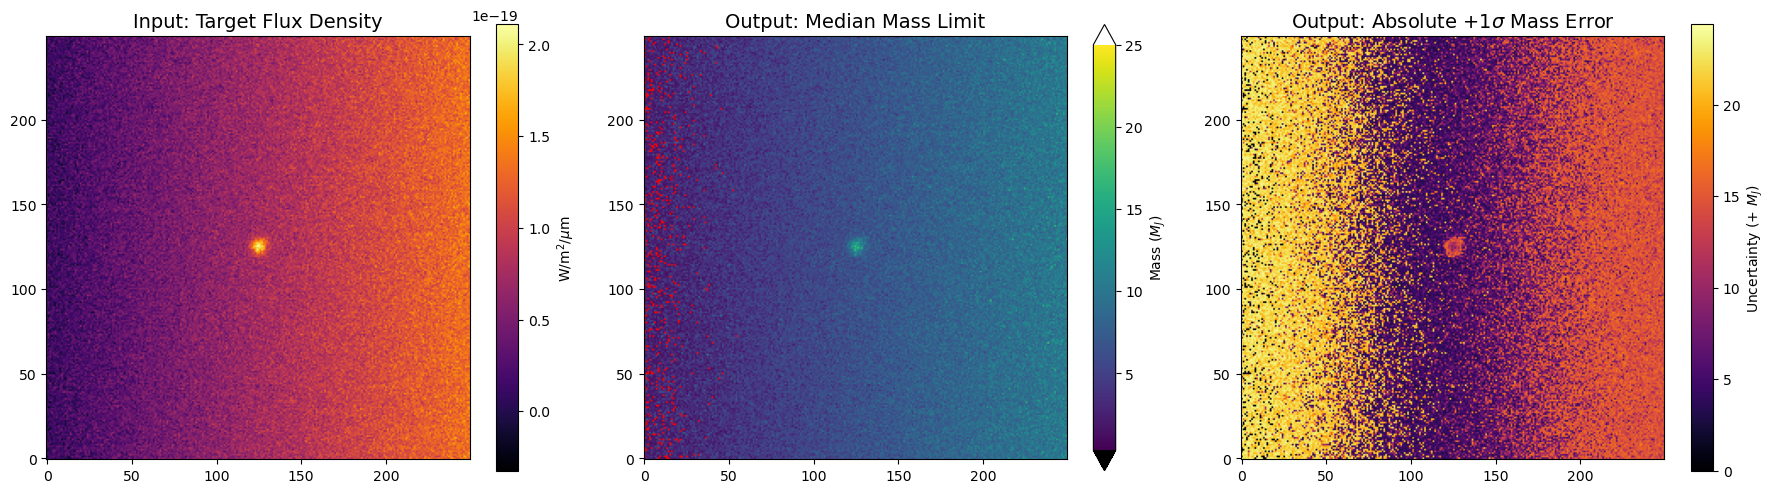

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Input Flux
im0 = axes[0].imshow(limit_w_m2_um, cmap='inferno', origin='lower')
axes[0].set_title("Input: Target Flux Density", fontsize=14)
plt.colorbar(im0, ax=axes[0], label='W/m$^2$/$\mu$m')

# Panel 2: Mass Limit Map
cmap_mass = copy.copy(plt.cm.viridis)
cmap_mass.set_under('black')   
cmap_mass.set_over('white')    
cmap_mass.set_bad('red')       

im1 = axes[1].imshow(mass_map, cmap=cmap_mass, origin='lower', 
                     vmin=inverter.actual_min_mass, vmax=inverter.actual_max_mass)
axes[1].set_title("Output: Median Mass Limit", fontsize=14)
plt.colorbar(im1, ax=axes[1], label='Mass ($M_J$)', extend='both')

# Panel 3: Uncertainty Map
cmap_err = copy.copy(plt.cm.inferno)
cmap_err.set_bad('black') 
im2 = axes[2].imshow(err_map, cmap=cmap_err, origin='lower', vmin=0.0)
axes[2].set_title("Output: Absolute +1$\sigma$ Mass Error", fontsize=14)
plt.colorbar(im2, ax=axes[2], label='Uncertainty (+ $M_J$)')

plt.tight_layout()
plt.show()